# Pre-Processing


## Setup

In [1]:
# Magic Codes 
%load_ext autoreload
%autoreload 2

In [2]:
# IMPORTS

from us_used_vehicle_resales.features import engineer_features
from us_used_vehicle_resales.cleaning import clean_data

import us_used_vehicle_resales as wg  

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, HTML

In [3]:
# SETTINGS

# Global Notebook Style
display(HTML("<style>table { margin-left: 0 !important; }</style>"))

# Global Pandas Options
pd.options.display.float_format = '{:.4f}'.format
pd.set_option('display.memory_usage', 'deep')

In [4]:
# CONSTANTS

TARGET = 'IsBadBuy'
DATA_PATH_INPUT = '../data/02_interim/'
DATA_PATH_OUTPUT = '../data/03_processed/'

tracker = wg.ModelTracker()    

## Data Loading

In [5]:
# LOADING DATA

wg.print_header('Engineering Started')

X_train, X_test, y_train, y_test = wg.load_split_data(folder=DATA_PATH_INPUT)

wg.print_footer()




~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ENGINEERING STARTED
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
🚀 Daten aus '../data/02_interim/' geladen.

Shapes: 
Train (52496, 32) 
Test (13124, 32)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~




## Data Cleaning

In [6]:
# DATA CLEANING 

wg.inspect_data(X_train, name='Raw Train-Data')

X_train_clean = clean_data(X_train)




~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
DATA REPORT: RAW TRAIN-DATA
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Dimensions & Global Quality
----------------------------------------


,Metrik,Wert
0,Zeilen,52496
1,Spalten,32
2,Duplikate (Gesamt),0
3,Duplikate (%),0.0%



Detaillierte Spalten-Qualität (Missing & Duplicates)
----------------------------------------


,Spalte,Dtype,Missing Values (NaN),Missing %,Unique Values,Col Duplicates
0,PRIMEUNIT,category,50017,95.2800,2,52493
1,AUCGUART,category,50017,95.2800,2,52493
2,WheelType,category,2304,4.3900,3,52492
3,WheelTypeID,category,2302,4.3900,4,52491
4,Trim,category,1683,3.2100,129,52366
5,MMRCurrentRetailCleanPrice,float64,226,0.4300,12146,40349
6,MMRCurrentRetailAveragePrice,float64,226,0.4300,11587,40908
7,MMRCurrentAuctionCleanPrice,float64,226,0.4300,10467,42028
8,MMRCurrentAuctionAveragePrice,float64,226,0.4300,9648,42847
9,VehBCost,float64,44,0.0800,1935,50560



Structure & NaN-Values
----------------------------------------


...


Numerical Statistic
----------------------------------------


,count,mean,std,min,25%,50%,75%,max
VehYear,52496.0000,2005.3400,1.7300,2001.0000,2004.0000,2005.0000,2007.0000,2010.0000
VehicleAge,52496.0000,4.1800,1.7100,0.0000,3.0000,4.0000,5.0000,9.0000
VehOdo,52496.0000,71497.3500,14577.0200,5368.0000,61793.5000,73371.0000,82457.0000,115717.0000
MMRAcquisitionAuctionAveragePrice,52484.0000,6124.9400,2449.4200,0.0000,4273.0000,6098.0000,7766.0000,35722.0000
MMRAcquisitionAuctionCleanPrice,52484.0000,7369.5100,2707.9300,0.0000,5406.7500,7307.0000,9024.2500,36859.0000
MMRAcquisitionRetailAveragePrice,52484.0000,8496.0700,3145.6600,0.0000,6275.7500,8447.0000,10661.0000,39080.0000
MMRAcquisitonRetailCleanPrice,52484.0000,9850.3700,3373.7900,0.0000,7490.0000,9794.0000,12111.0000,41482.0000
MMRCurrentAuctionAveragePrice,52270.0000,6130.6900,2424.7700,0.0000,4279.0000,6067.0000,7737.0000,35722.0000
MMRCurrentAuctionCleanPrice,52270.0000,7389.0300,2674.7600,0.0000,5417.0000,7316.0000,9015.7500,36859.0000
MMRCurrentRetailAveragePrice,52270.0000,8775.0500,3081.1100,0.0000,6543.2500,8730.0000,10913.0000,39080.0000



EDA ToDos
----------------------------------------
[CHECKS]
  - Fehlwerte in Spalten ['Trim', 'SubModel', 'Color', 'Transmission', 'WheelTypeID', 'WheelType', 'Nationality', 'Size', 'TopThreeAmericanName', 'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 'PRIMEUNIT', 'AUCGUART', 'VehBCost']. Imputation prüfen.
  - Hohe Fehlwerte (>10%) in Spalten ['PRIMEUNIT', 'AUCGUART']. Imputation prüfen.

[VISUALISIERUNGS]
  - Boxplot für 'VehicleAge' (448 q1/q3 +/- 1.5)
  - Boxplot für 'VehOdo' (227 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitionAuctionAveragePrice' (343 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitionAuctionCleanPrice' (568 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitionRetailAveragePrice' (198 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitonRetailCleanPrice' (860 q1/q3 +

Phase,Status,Key Finding,Next Step (Action)
Completeness,⚠️ WARN,"0 Dups, Max 95.3% NaNs",Drop Duplicates / Impute NaNs
Integrity,✅ OK,Keine Logikfehler,Filtering / Drop Invalid Rows
Distribution,ℹ️ INFO,"Outliers in: VehicleAge, VehOdo, MMRAcquisitionAuctionAveragePrice...",Clipping / Winsorizing / Scaling
Relationships,⚠️ WARN,"Multikollinearität: ['VehYear', 'VehicleAge', 'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice']",Feature Selection (Drop redundant)
Engineering,💡 IDEA,"High Card: ['Make', 'Model', 'Trim', 'SubModel', 'Color', 'BYRNO', 'VNZIP1', 'VNST'] | Low Var: []",Encoding / Interaction / Grouping


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


 DATA CLEANING & SUCCESS REPORT 
KAPITEL 1: COMPLETENESS
  - Erkannt: 106348 kategoriale Lücken
  - Aktion:  106348 gefüllt mit 'Unknown'

KAPITEL 2: INTEGRITY
  - Erkannt:    621 Logik-Fehler (< 100$, Alter, Odo)
  - Aktion:     621 geheilt via Imputation
  - Aktion:       0 unrettbar gelöscht
-------------------------------------------------------
ENDERGEBNIS:
  - Datensätze (Rows):  52496
  - Retention Rate:    100.00%
  - Churn Rate:          0.00%



In [7]:
X_train_clean

,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,Transmission,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
37348,2010-11-17,MANHEIM,2008,2,CHEVROLET,COBALT,LS,2D COUPE LS,BLACK,AUTO,...,9798.0000,10445.0000,Unknown,Unknown,19638,33809,FL,6850.0000,0,728.0000
38894,2010-03-16,MANHEIM,2005,5,CHEVROLET,TRAILBLAZER 2WD 6C,LS,4D SUV 4.2L,SILVER,AUTO,...,11523.0000,12994.0000,Unknown,Unknown,19638,34761,FL,8085.0000,0,1341.0000
56871,2010-01-27,MANHEIM,2006,4,CHRYSLER,PT CRUISER,Tou,4D SEDAN,SILVER,AUTO,...,8126.0000,9545.0000,Unknown,Unknown,20833,78219,TX,5825.0000,0,1215.0000
44648,2010-07-06,MANHEIM,2003,7,CHEVROLET,TRAILBLAZER 4WD 6C,LS,4D SUV 4.2L LS,BROWN,AUTO,...,8987.0000,10535.0000,Unknown,Unknown,20207,77041,TX,7400.0000,0,2651.0000
11413,2009-01-12,MANHEIM,2005,4,JEEP,LIBERTY 4WD V6 3.7L,Spo,4D SUV,BLUE,AUTO,...,9348.0000,10830.0000,Unknown,Unknown,18880,27542,NC,6600.0000,0,754.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8584,2010-09-23,MANHEIM,2005,5,CHEVROLET,COBALT,Bas,4D SEDAN,BLUE,AUTO,...,6763.0000,8917.0000,Unknown,Unknown,23657,92337,CA,5355.0000,0,803.0000
29724,2009-02-09,MANHEIM,2005,4,MERCURY,MARINER 4WD V6 3.0L,Bas,4D SUV 3.0L,WHITE,AUTO,...,7835.0000,9516.0000,Unknown,Unknown,21973,27542,NC,7400.0000,0,1503.0000
51247,2009-05-20,OTHER,2006,3,PONTIAC,GRAND PRIX 3.8L V6 S,Bas,4D SEDAN,OTHER,AUTO,...,7917.0000,9733.0000,Unknown,Unknown,19638,35004,AL,7600.0000,0,1703.0000
63120,2010-07-20,MANHEIM,2002,8,FORD,EXPEDITION 4WD V8,Edd,4D SUV 5.4L EDDIE BAUER,BLACK,AUTO,...,8361.0000,9396.0000,Unknown,Unknown,52492,28625,NC,8910.0000,0,1930.0000


In [8]:
# BASIC STATISTICS

wg.inspect_data(X_train_clean, name='Cleaned Train-Data')




~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
DATA REPORT: CLEANED TRAIN-DATA
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Dimensions & Global Quality
----------------------------------------


,Metrik,Wert
0,Zeilen,52496
1,Spalten,32
2,Duplikate (Gesamt),0
3,Duplikate (%),0.0%



Detaillierte Spalten-Qualität (Missing & Duplicates)
----------------------------------------


,Spalte,Dtype,Missing Values (NaN),Missing %,Unique Values,Col Duplicates
0,PurchDate,datetime64[ns],0,0.0000,515,51981
1,Auction,category,0,0.0000,3,52493
2,VehYear,int64,0,0.0000,10,52486
3,VehicleAge,int64,0,0.0000,10,52486
4,Make,category,0,0.0000,29,52467
5,Model,category,0,0.0000,1001,51495
6,Trim,category,0,0.0000,130,52366
7,SubModel,category,0,0.0000,804,51692
8,Color,category,0,0.0000,17,52479
9,Transmission,category,0,0.0000,4,52492



Structure & NaN-Values
----------------------------------------


...


Numerical Statistic
----------------------------------------


,count,mean,std,min,25%,50%,75%,max
VehYear,52496.0000,2005.3400,1.7300,2001.0000,2004.0000,2005.0000,2007.0000,2010.0000
VehicleAge,52496.0000,4.1800,1.7100,0.0000,3.0000,4.0000,5.0000,9.0000
VehOdo,52496.0000,71497.3500,14577.0200,5368.0000,61793.5000,73371.0000,82457.0000,115717.0000
MMRAcquisitionAuctionAveragePrice,52496.0000,6193.9500,2371.5100,884.0000,4342.0000,6144.0000,7779.0000,35722.0000
MMRAcquisitionAuctionCleanPrice,52496.0000,7453.2700,2603.8400,1076.0000,5483.0000,7361.0000,9040.0000,36859.0000
MMRAcquisitionRetailAveragePrice,52496.0000,8594.9100,3024.7700,1455.0000,6374.7500,8481.0000,10686.0000,39080.0000
MMRAcquisitonRetailCleanPrice,52496.0000,9965.0500,3220.1200,1662.0000,7574.0000,9838.0000,12138.0000,41482.0000
MMRCurrentAuctionAveragePrice,52496.0000,6173.1900,2377.6300,369.0000,4318.0000,6096.0000,7749.0000,35722.0000
MMRCurrentAuctionCleanPrice,52496.0000,7440.0300,2610.8400,494.0000,5467.0000,7349.0000,9022.0000,36859.0000
MMRCurrentRetailAveragePrice,52496.0000,8828.5400,3003.1400,899.0000,6589.0000,8753.0000,10920.0000,39080.0000



EDA ToDos
----------------------------------------
[VISUALISIERUNGS]
  - Boxplot für 'VehicleAge' (448 q1/q3 +/- 1.5)
  - Boxplot für 'VehOdo' (227 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitionAuctionAveragePrice' (366 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitionAuctionCleanPrice' (593 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitionRetailAveragePrice' (218 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitonRetailCleanPrice' (284 q1/q3 +/- 1.5)
  - Boxplot für 'MMRCurrentAuctionAveragePrice' (396 q1/q3 +/- 1.5)
  - Boxplot für 'MMRCurrentAuctionCleanPrice' (596 q1/q3 +/- 1.5)
  - Boxplot für 'MMRCurrentRetailAveragePrice' (200 q1/q3 +/- 1.5)
  - Boxplot für 'MMRCurrentRetailCleanPrice' (298 q1/q3 +/- 1.5)
  - Boxplot für 'VehBCost' (134 q1/q3 +/- 1.5)
  - Boxplot für 'IsOnlineSale' (1342 q1/q3 +/- 1.5)
  - Boxplot für 'WarrantyCost' (603 q1/q3 +/- 1.5)
  - Countplot für 'Auction' (3 Klassen prüfen)
  - Countplot für 'Transmission' (4 Klassen prüfen)
  - Countplot für 'WheelTypeID' (5 Klass

Phase,Status,Key Finding,Next Step (Action)
Completeness,✅ OK,"0 Dups, Max 0.0% NaNs",Drop Duplicates / Impute NaNs
Integrity,✅ OK,Keine Logikfehler,Filtering / Drop Invalid Rows
Distribution,ℹ️ INFO,"Outliers in: VehicleAge, VehOdo, MMRAcquisitionAuctionAveragePrice...",Clipping / Winsorizing / Scaling
Relationships,⚠️ WARN,"Multikollinearität: ['VehYear', 'VehicleAge', 'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 'VehBCost']",Feature Selection (Drop redundant)
Engineering,💡 IDEA,"High Card: ['Make', 'Model', 'Trim', 'SubModel', 'Color', 'BYRNO', 'VNZIP1', 'VNST'] | Low Var: []",Encoding / Interaction / Grouping


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~




# Feature Engineering

In [9]:
# FEATURE ENGINEERING

X_train_feat = engineer_features(X_train_clean)

 FEATURE ENGINEERING REPORT 
Status: Enrichment Complete
Added Features (9):
   [+] feat_price_ratio
   [+] feat_price_diff
   [+] feat_market_trend
   [+] feat_miles_per_year
   [+] feat_warranty_ratio
   [+] feat_age_group
   [+] feat_odo_risk
   [+] feat_price_cat
   [+] feat_warranty_peak
Total Columns now: 41



In [10]:


new_features = list(set(X_train_feat.columns) - set(X_train_clean.columns))

print(f"newfeatures: {len(new_features)}")
print(f"list: {new_features}")




newfeatures: 9
list: ['feat_odo_risk', 'feat_warranty_peak', 'feat_miles_per_year', 'feat_market_trend', 'feat_age_group', 'feat_price_ratio', 'feat_warranty_ratio', 'feat_price_cat', 'feat_price_diff']


## Statistics




~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
CHECK CORRELATIONS
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Starke Korrelationen (> 0.4):


Feature A,Feature B,Correlation
MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,0.99
MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,0.99
MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,0.99
MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,0.99
VehYear,VehicleAge,0.96
MMRAcquisitionAuctionAveragePrice,MMRCurrentAuctionAveragePrice,0.95
MMRAcquisitionAuctionCleanPrice,MMRCurrentAuctionCleanPrice,0.95
MMRAcquisitionAuctionAveragePrice,MMRCurrentAuctionCleanPrice,0.95
MMRAcquisitionAuctionCleanPrice,MMRCurrentAuctionAveragePrice,0.94
MMRAcquisitionRetailAveragePrice,MMRCurrentRetailAveragePrice,0.94


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~




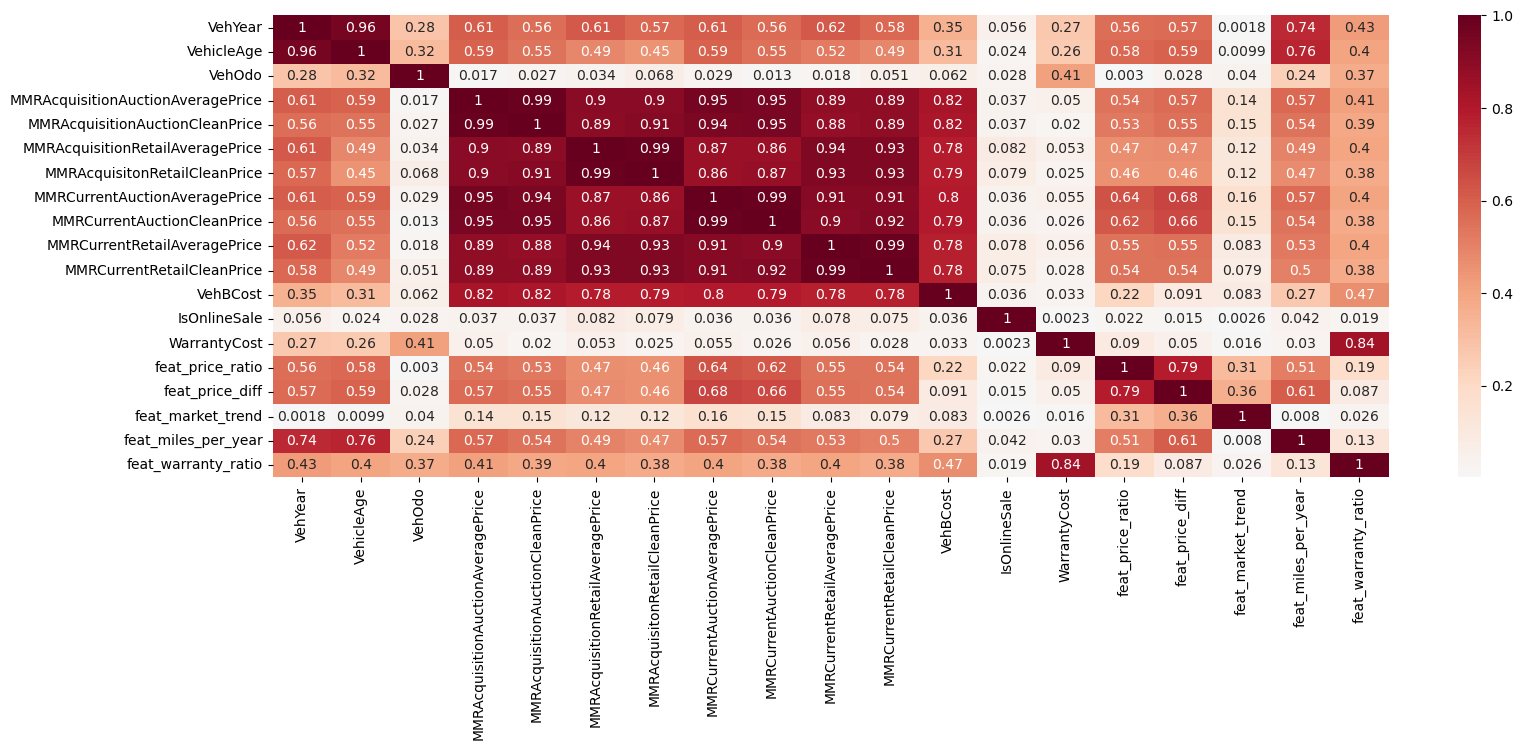

In [11]:
# CORRELATIONS CHECK 

wg.inspect_correlations(X_train_feat, pairplot=False)

In [12]:
# Statistic
wg.inspect_data(X_train_feat, name='Feature Enriched Train-Data')




~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
DATA REPORT: FEATURE ENRICHED TRAIN-DATA
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Dimensions & Global Quality
----------------------------------------


,Metrik,Wert
0,Zeilen,52496
1,Spalten,41
2,Duplikate (Gesamt),0
3,Duplikate (%),0.0%



Detaillierte Spalten-Qualität (Missing & Duplicates)
----------------------------------------


,Spalte,Dtype,Missing Values (NaN),Missing %,Unique Values,Col Duplicates
0,PurchDate,datetime64[ns],0,0.0000,515,51981
1,Auction,category,0,0.0000,3,52493
2,VehYear,int64,0,0.0000,10,52486
3,VehicleAge,int64,0,0.0000,10,52486
4,Make,category,0,0.0000,29,52467
5,Model,category,0,0.0000,1001,51495
6,Trim,category,0,0.0000,130,52366
7,SubModel,category,0,0.0000,804,51692
8,Color,category,0,0.0000,17,52479
9,Transmission,category,0,0.0000,4,52492



Structure & NaN-Values
----------------------------------------


...


Numerical Statistic
----------------------------------------


,count,mean,std,min,25%,50%,75%,max
VehYear,52496.0000,2005.3400,1.7300,2001.0000,2004.0000,2005.0000,2007.0000,2010.0000
VehicleAge,52496.0000,4.1800,1.7100,0.0000,3.0000,4.0000,5.0000,9.0000
VehOdo,52496.0000,71497.3500,14577.0200,5368.0000,61793.5000,73371.0000,82457.0000,115717.0000
MMRAcquisitionAuctionAveragePrice,52496.0000,6193.9500,2371.5100,884.0000,4342.0000,6144.0000,7779.0000,35722.0000
MMRAcquisitionAuctionCleanPrice,52496.0000,7453.2700,2603.8400,1076.0000,5483.0000,7361.0000,9040.0000,36859.0000
MMRAcquisitionRetailAveragePrice,52496.0000,8594.9100,3024.7700,1455.0000,6374.7500,8481.0000,10686.0000,39080.0000
MMRAcquisitonRetailCleanPrice,52496.0000,9965.0500,3220.1200,1662.0000,7574.0000,9838.0000,12138.0000,41482.0000
MMRCurrentAuctionAveragePrice,52496.0000,6173.1900,2377.6300,369.0000,4318.0000,6096.0000,7749.0000,35722.0000
MMRCurrentAuctionCleanPrice,52496.0000,7440.0300,2610.8400,494.0000,5467.0000,7349.0000,9022.0000,36859.0000
MMRCurrentRetailAveragePrice,52496.0000,8828.5400,3003.1400,899.0000,6589.0000,8753.0000,10920.0000,39080.0000



EDA ToDos
----------------------------------------
[CHECKS]
  - Negative Werte in 'feat_price_diff' (Min: -10744.0). Plausibilität prüfen!
  - Negative Werte in 'feat_market_trend' (Min: -10729.0). Plausibilität prüfen!

[VISUALISIERUNGS]
  - Boxplot für 'VehicleAge' (448 q1/q3 +/- 1.5)
  - Boxplot für 'VehOdo' (227 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitionAuctionAveragePrice' (366 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitionAuctionCleanPrice' (593 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitionRetailAveragePrice' (218 q1/q3 +/- 1.5)
  - Boxplot für 'MMRAcquisitonRetailCleanPrice' (284 q1/q3 +/- 1.5)
  - Boxplot für 'MMRCurrentAuctionAveragePrice' (396 q1/q3 +/- 1.5)
  - Boxplot für 'MMRCurrentAuctionCleanPrice' (596 q1/q3 +/- 1.5)
  - Boxplot für 'MMRCurrentRetailAveragePrice' (200 q1/q3 +/- 1.5)
  - Boxplot für 'MMRCurrentRetailCleanPrice' (298 q1/q3 +/- 1.5)
  - Boxplot für 'VehBCost' (134 q1/q3 +/- 1.5)
  - Boxplot für 'IsOnlineSale' (1342 q1/q3 +/- 1.5)
  - Boxplot für 'War

Phase,Status,Key Finding,Next Step (Action)
Completeness,✅ OK,"0 Dups, Max 0.0% NaNs",Drop Duplicates / Impute NaNs
Integrity,✅ OK,Keine Logikfehler,Filtering / Drop Invalid Rows
Distribution,ℹ️ INFO,"Outliers in: VehicleAge, VehOdo, MMRAcquisitionAuctionAveragePrice...",Clipping / Winsorizing / Scaling
Relationships,⚠️ WARN,"Multikollinearität: ['VehYear', 'VehicleAge', 'MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 'VehBCost', 'WarrantyCost', 'feat_warranty_ratio']",Feature Selection (Drop redundant)
Engineering,💡 IDEA,"High Card: ['Make', 'Model', 'Trim', 'SubModel', 'Color', 'BYRNO', 'VNZIP1', 'VNST'] | Low Var: []",Encoding / Interaction / Grouping


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~




# Final Features Export

In [13]:
# --- PROCESSED DATA EXPORT ---

wg.save_processed_data(X_train_feat, y_train, folder=DATA_PATH_OUTPUT, name='train')

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
PROCESSED TRAIN DATA EXPORT
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
🚀 X-Features: 52496 rows | 41 cols
🎯 y-Labels:   Gespeichert (52496 Zeilen)
📂 Location:   ../data/03_processed/
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


# Features Insights

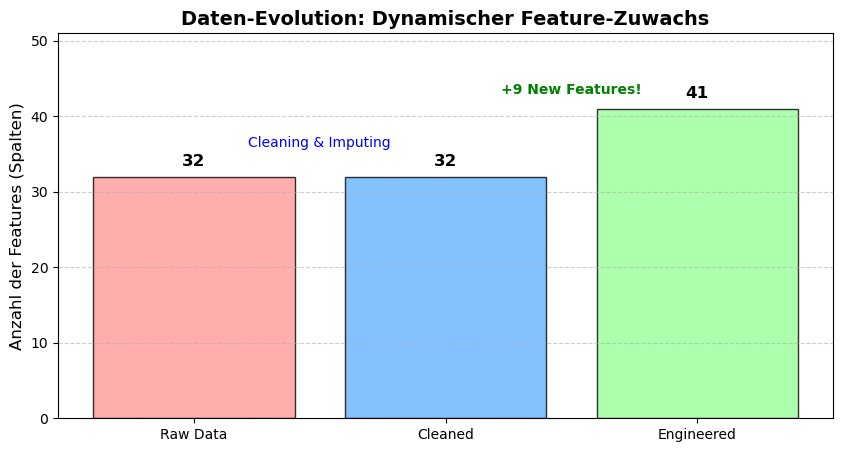

In [14]:
import matplotlib.pyplot as plt

# 1. Dynamisches Auslesen der Spaltenanzahl aus deinen DataFrames
# Wir gehen davon aus, dass deine DFs so heißen:
# df_raw (Original), X_train (Cleaned), X_train_feat (Engineered)
stages = ['Raw Data', 'Cleaned', 'Engineered']
column_counts = [
    X_train.shape[1],        # Die ursprünglichen 32 Spalten
    X_train_clean.shape[1],       # Nach dem Cleaning (meist identisch, außer Drop von IDs)
    X_train_feat.shape[1]   # Inklusive deiner 9 neuen feat_-Spalten
]

# 2. Plotting
plt.figure(figsize=(10, 5))
colors = ['#ff9999', '#66b3ff', '#99ff99']
bars = plt.bar(stages, column_counts, color=colors, edgecolor='black', alpha=0.8)

# 3. Styling
plt.ylabel('Anzahl der Features (Spalten)', fontsize=12)
plt.title('Daten-Evolution: Dynamischer Feature-Zuwachs', fontsize=14, fontweight='bold')
plt.ylim(0, max(column_counts) + 10) # Etwas Platz nach oben für die Labels
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 4. Werte über die Balken schreiben
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# 5. Annotation: Was ist passiert?
plt.text(0.5, max(column_counts)-5, "Cleaning & Imputing", ha='center', color='blue', fontsize=10)
plt.text(1.5, max(column_counts)+2, f"+{column_counts[2]-column_counts[1]} New Features!", 
         ha='center', color='green', fontweight='bold', fontsize=10)

plt.show()

## 🛠️ Strategisches Feature Engineering: "Informing the Model"

Um die Vorhersagekraft unseres Modells zu maximieren, nutzen wir gezielte Techniken, um "rohe" Daten in wertvolle Signale zu verwandeln.

### 1. Informing the Model (Modell-Führung)
Durch das Erstellen von Features wie `feat_price_ratio`, `feat_miles_per_year` und `feat_warranty_ratio` betreiben wir **Informing the Model**. 
* **Was das ist:** Wir geben dem Algorithmus mathematische Abkürzungen. Anstatt dass das Modell mühsam selbst lernen muss, dass der Preis im Verhältnis zum Marktwert wichtig ist, liefern wir das Ergebnis direkt.
* **Wo es hilft:** Es beschleunigt das Training und hilft dem Modell, logische Zusammenhänge (z. B. Überzahlung beim Einkauf) sofort als Risiko zu erkennen.

### 2. Feature Binning (Diskretisierung)
Mit den Features `feat_age_group`, `feat_odo_risk` und `feat_warranty_peak` nutzen wir **Feature Binning**.
* **Was das ist:** Wir wandeln kontinuierliche Zahlen (0 bis 200.000 Meilen) in logische "Schubladen" (Bins) um (z. B. "Geringe Laufleistung", "Risiko-Bereich").
* **Wo es hilft:** Es macht das Modell robuster gegen Ausreißer und erlaubt es, **nicht-lineare Muster** (wie U-Kurven beim Risiko) einfach zu erfassen.

### 3. Messung des "Information Risk Spread"
Um den Erfolg zu prüfen, messen wir die **Risiko-Spanne** jedes Merkmals.
* **Das Verfahren:** Wir vergleichen die Gruppe mit dem höchsten Bad-Buy-Risiko mit der Gruppe mit dem niedrigsten Risiko innerhalb eines Features.
* **Ziel:** Je größer dieser "Spread" (die Spanne), desto besser kann das Feature "gute" von "schlechten" Autos trennen. Dies ist unsere Erfolgskontrolle vor dem eigentlichen Training.

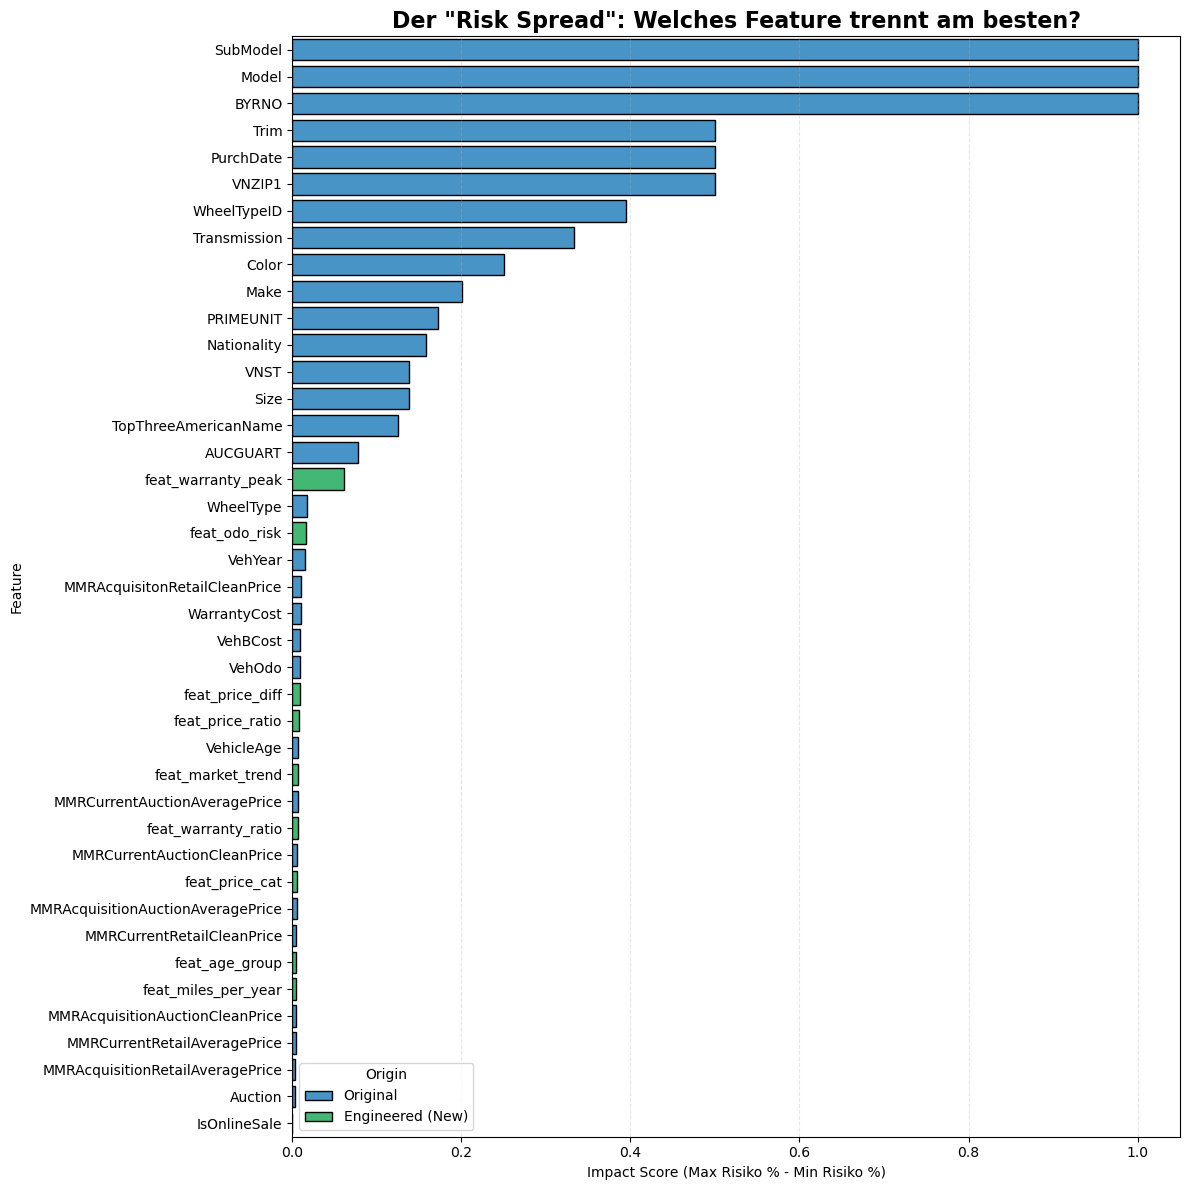

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Vorbereitung der Feature-Listen
original_cols = list(X_train.columns)
new_cols = [c for c in X_train_feat.columns if c.startswith('feat_')]
all_to_check = original_cols + new_cols

impact_data = []

# 2. Berechnung des Risk Spreads (Fairer Vergleich)
for col in all_to_check:
    if col not in X_train_feat.columns: continue
    
    vals = X_train_feat[col]
    target = pd.Series(y_train.values)
    
    # Einheitliches Binning für numerische Werte
    if vals.dtype in ['float64', 'int64']:
        try:
            groups = pd.qcut(vals, q=5, duplicates='drop')
        except: continue
    else:
        groups = vals
        
    # Spanne berechnen (Max Risiko - Min Risiko)
    stats = target.groupby(groups, observed=True).mean()
    risk_spread = stats.max() - stats.min()

    impact_data.append({
        'Feature': col,
        'Risk_Value': risk_spread,
        'Origin': 'Engineered (New)' if col.startswith('feat_') else 'Original'
    })

# 3. Ranking erstellen
df_rank = pd.DataFrame(impact_data).sort_values(by='Risk_Value', ascending=False)

# 4. Plotting
plt.figure(figsize=(12, 12))
sns.barplot(
    data=df_rank, x='Risk_Value', y='Feature', hue='Origin',
    palette={'Engineered (New)': '#2ecc71', 'Original': '#3498db'},
    edgecolor='black'
)

plt.title('Der "Risk Spread": Welches Feature trennt am besten?', fontsize=16, fontweight='bold')
plt.xlabel('Impact Score (Max Risiko % - Min Risiko %)')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### 🧠 Die Logik hinter den Top-Ranking Features

Im ersten Moment wirken Features wie `Trim`, `SubModel` oder `VNZIP1` wie reiner Text ohne mathematischen Wert. Doch unser **Risk Spread Plot** zeigt: Sie sind die stärksten Risikotreiber. Hier ist die Logik dahinter:

| Feature | Warum es logisch ist (Hypothese) | Impact-Grund |
| :--- | :--- | :--- |
| **VNZIP1 / Region** | **Der Standort-Effekt:** Klima (Rost!), Straßenqualität und regionale Auktions-Standards. Ein Auto aus Florida hat ein anderes Risiko als eines aus dem "Rust Belt". | Regionales Cluster |
| **Trim / SubModel** | **Die Bauart-Qualität:** Bestimmte Ausstattungslinien (z. B. "Base" vs. "Luxury") haben oft spezifische technische Schwachstellen oder wurden von unterschiedlichen Haltergruppen (Heizer vs. Rentner) gefahren. | Technisches Cluster |
| **Model** | **Der Serien-Ruf:** Manche Modellreihen haben bekannte Serienfehler (Getriebe, Elektronik), die das Risiko massiv nach oben treiben, egal wie alt das Auto ist. | Qualitäts-Indikator |
| **Color** | **Psychologie & Pflege:** Statistisch werden bestimmte Farben (z. B. Weiß/Silber) oft als Flottenfahrzeuge genutzt, während ausgefallene Farben oft Privatbesitz sind. | Nutzungsproxy |
| **WheelType** | **Wartungshinweis:** Alufelgen vs. Stahlfelgen lassen oft auf die ursprüngliche Preisklasse und die Pflegebereitschaft des Vorbesitzers schließen. | Prestigefaktor |

**Fazit:** Diese Features sind mächtig, weil sie **Expertenwissen bündeln**, das in nackten Zahlen wie `VehBCost` nicht direkt enthalten ist.